# 03 — Ước lượng P_hat + kiểm chứng Chapman-Kolmogorov (§4.1, §4.3)

Trạng thái: **FROZEN** (2026-09-22, full run 150.000 khoản vay — xem `.claude/skills/notebook-first-model-dev/SKILL.md`).

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd())))

from utils.markov import mle_transition_matrix, matrix_power, frobenius_deviation
from utils.transitions import build_pair_counts, pairs_to_count_matrix

In [ ]:
SUFFIX = "full"  # FROZEN o full; doi lai "smoke" chi de kiem tra nhanh, khong ghi de artifact chinh thuc

DATA_DIR = os.path.join("..", "data", "processed")
FIG_DIR = os.path.join("..", "outputs", "figures")
TABLE_DIR = os.path.join("..", "outputs", "tables")
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

STATE_NAMES = ["Current", "30 DPD", "60 DPD", "90+ DPD", "Default", "Prepaid"]
N_STATES = 6
ABSORBING = [4, 5]

## 1. Load estimation set

In [3]:
est_path = os.path.join(DATA_DIR, f"estimation_set_{SUFFIX}.parquet")
df = pd.read_parquet(est_path)
print(f"Đọc {est_path}: shape={df.shape}")
df["state"].value_counts().sort_index()

Đọc ..\data\processed\estimation_set_full.parquet: shape=(7253423, 6)


state
0    6915017
1      54919
2      16997
3      24977
4     136283
5     105230
Name: count, dtype: int64

## 2. Ghép cặp liên tiếp (k=1) cho P_hat

In [4]:
pairs_1 = build_pair_counts(df, k=1)
n_ij = pairs_to_count_matrix(pairs_1, n_states=N_STATES)
print(f"Số cặp k=1 hợp lệ: {len(pairs_1)} / số dòng trajectory: {len(df)}")
print("Tổng theo hàng (n_i·):", n_ij.sum(axis=1))
pd.DataFrame(n_ij, index=STATE_NAMES, columns=STATE_NAMES)

Số cặp k=1 hợp lệ: 7103422 / số dòng trajectory: 7253423
Tổng theo hàng (n_i·): [6875554.   54505.   16903.   24906.  131554.       0.]


,Current,30 DPD,60 DPD,90+ DPD,Default,Prepaid
Current,6736463.0,35399.0,160.0,47.0,11.0,103474.0
30 DPD,23397.0,17552.0,12474.0,43.0,6.0,1033.0
60 DPD,2544.0,1606.0,3830.0,8655.0,8.0,260.0
90+ DPD,2761.0,318.0,533.0,16232.0,4703.0,359.0
Default,0.0,0.0,0.0,0.0,131554.0,0.0
Prepaid,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Ước lượng P_hat (MLE)

In [5]:
P_hat = mle_transition_matrix(n_ij, absorbing_states=ABSORBING)
print("Tổng theo hàng (kỳ vọng ~1, trừ hàng NaN nếu thiếu quan sát):", np.nansum(P_hat, axis=1))
pd.DataFrame(P_hat, index=STATE_NAMES, columns=STATE_NAMES).round(4)

mle_transition_matrix: trạng thái [5] không có quan sát chuyển nào (hàng NaN)


Tổng theo hàng (kỳ vọng ~1, trừ hàng NaN nếu thiếu quan sát): [1. 1. 1. 1. 1. 1.]


,Current,30 DPD,60 DPD,90+ DPD,Default,Prepaid
Current,0.9798,0.0051,0.0000,0.0000,0.0000,0.0150
30 DPD,0.4293,0.3220,0.2289,0.0008,0.0001,0.0190
60 DPD,0.1505,0.0950,0.2266,0.5120,0.0005,0.0154
90+ DPD,0.1109,0.0128,0.0214,0.6517,0.1888,0.0144
Default,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
Prepaid,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000


## 4. Heatmap P_hat

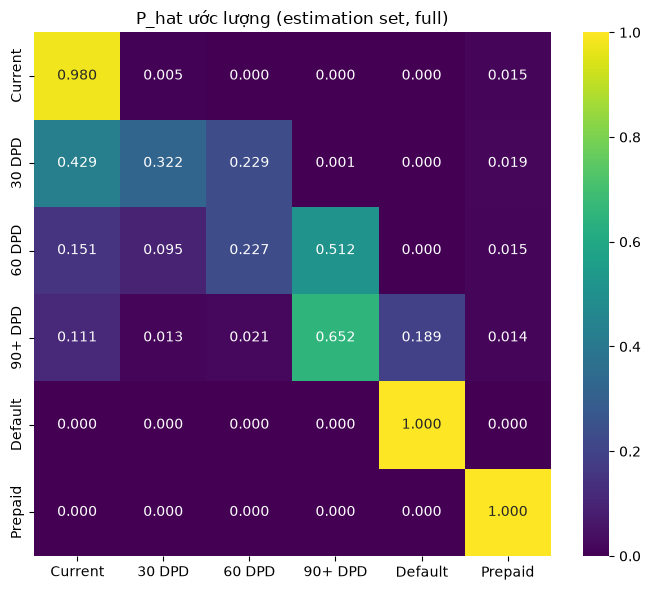

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(P_hat, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=STATE_NAMES, yticklabels=STATE_NAMES, ax=ax)
ax.set_title(f"P_hat ước lượng (estimation set, {SUFFIX})")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "heatmap_P_hat.png"), dpi=150)
plt.show()

## 5. Bảng số quan sát mỗi trạng thái (§4.1)

In [8]:
n_i_dot = n_ij.sum(axis=1)
observed_table = pd.DataFrame({
    "state": STATE_NAMES,
    "n_i_dot": n_i_dot,
    "pct": n_i_dot / n_i_dot.sum(),
})
observed_table.to_csv(os.path.join(TABLE_DIR, "observed_counts_by_state.csv"), index=False)
observed_table

,state,n_i_dot,pct
0,Current,6875554.0,0.967921
1,30 DPD,54505.0,0.007673
2,60 DPD,16903.0,0.002380
3,90+ DPD,24906.0,0.003506
4,Default,131554.0,0.018520
5,Prepaid,0.0,0.000000


## 6. Ghép cặp cách 3 tháng (k=3) cho P_hat^(3) trực tiếp

In [9]:
pairs_3 = build_pair_counts(df, k=3)
n_ij_3 = pairs_to_count_matrix(pairs_3, n_states=N_STATES)
P_hat_3_direct = mle_transition_matrix(n_ij_3, absorbing_states=ABSORBING)
print(f"Số cặp k=3 hợp lệ: {len(pairs_3)}")
pd.DataFrame(P_hat_3_direct, index=STATE_NAMES, columns=STATE_NAMES).round(4)

mle_transition_matrix: trạng thái [5] không có quan sát chuyển nào (hàng NaN)


Số cặp k=3 hợp lệ: 6803851


,Current,30 DPD,60 DPD,90+ DPD,Default,Prepaid
Current,0.9758,0.0059,0.0016,0.0010,0.0000,0.0157
30 DPD,0.5360,0.2315,0.0752,0.1442,0.0004,0.0128
60 DPD,0.2895,0.1075,0.1234,0.4640,0.0017,0.0139
90+ DPD,0.2140,0.0292,0.0237,0.1441,0.5808,0.0082
Default,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
Prepaid,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000


## 7. Kiểm chứng Chapman-Kolmogorov (§4.3)

In [10]:
P_hat_3_ck = matrix_power(P_hat, 3)
fro_norm, max_cell = frobenius_deviation(P_hat_3_ck, P_hat_3_direct)
print("(P_hat^(1))^3:")
display(pd.DataFrame(P_hat_3_ck, index=STATE_NAMES, columns=STATE_NAMES).round(4))
print("P_hat^(3) trực tiếp:")
display(pd.DataFrame(P_hat_3_direct, index=STATE_NAMES, columns=STATE_NAMES).round(4))
print(f"Frobenius norm sai lệch: {fro_norm:.6f}")
print(f"Sai lệch tuyệt đối lớn nhất từng ô: {max_cell:.6f}")

(P_hat^(1))^3:


,Current,30 DPD,60 DPD,90+ DPD,Default,Prepaid
Current,0.9458,0.0072,0.0018,0.0006,0.0000,0.0445
30 DPD,0.6681,0.0576,0.0602,0.1413,0.0228,0.0500
60 DPD,0.3615,0.0343,0.0423,0.3362,0.1823,0.0434
90+ DPD,0.2438,0.0134,0.0177,0.2951,0.3942,0.0358
Default,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
Prepaid,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000


P_hat^(3) trực tiếp:


,Current,30 DPD,60 DPD,90+ DPD,Default,Prepaid
Current,0.9758,0.0059,0.0016,0.0010,0.0000,0.0157
30 DPD,0.5360,0.2315,0.0752,0.1442,0.0004,0.0128
60 DPD,0.2895,0.1075,0.1234,0.4640,0.0017,0.0139
90+ DPD,0.2140,0.0292,0.0237,0.1441,0.5808,0.0082
Default,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
Prepaid,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000


Frobenius norm sai lệch: 0.421953
Sai lệch tuyệt đối lớn nhất từng ô: 0.186636


## 8. Heatmap sai lệch CK

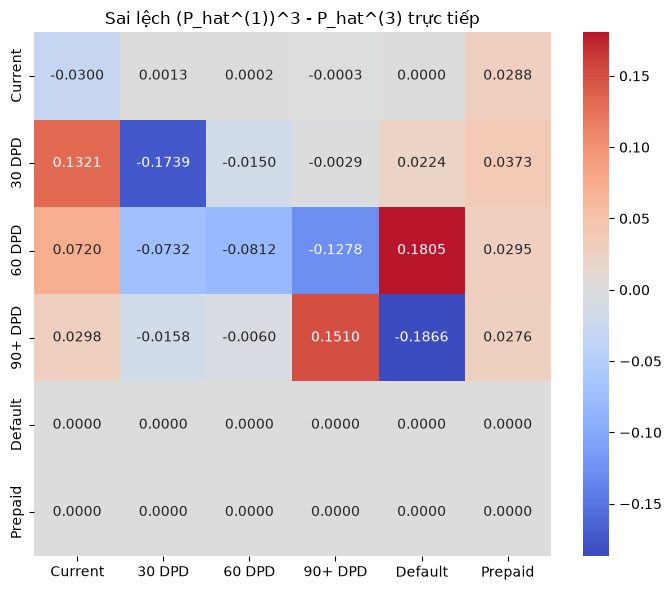

In [11]:
deviation = P_hat_3_ck - P_hat_3_direct
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(deviation, annot=True, fmt=".4f", cmap="coolwarm", center=0,
            xticklabels=STATE_NAMES, yticklabels=STATE_NAMES, ax=ax)
ax.set_title("Sai lệch (P_hat^(1))^3 - P_hat^(3) trực tiếp")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "heatmap_ck_deviation.png"), dpi=150)
plt.show()

## 9. Lưu bảng kết quả CK

In [12]:
ck_summary = pd.DataFrame({
    "metric": ["frobenius_norm", "max_abs_cell"],
    "value": [fro_norm, max_cell],
})
ck_summary.to_csv(os.path.join(TABLE_DIR, "ck_comparison.csv"), index=False)
ck_summary

,metric,value
0,frobenius_norm,0.421953
1,max_abs_cell,0.186636


## 10. Quyết định

Quyết định: Chấp nhận `P_hat` và kết quả kiểm chứng Chapman-Kolmogorov này làm đầu vào chính thức cho §4.1/§4.3 của báo cáo. Không chỉnh sửa gì thêm ở Phase 2 — sai lệch CK sẽ được kiểm định chính thức (accept/reject) ở Phase 3, không tự kết luận ở đây.

Lý do:
- `P_hat` hợp lý về mặt định tính: hàng Current ổn định cao (0,98); các hàng 30/60/90+DPD thể hiện rõ hiện tượng "cure" (roll ngược về state thấp hơn) — khớp quan sát thực tế trong `DATA_DICTIONARY.md` (kịch bản B, forbearance/thiên tai).
- Hàng Prepaid toàn NaN trong `n_ij` → bị ép identity đúng theo thiết kế `absorbing_states=[4,5]`. Đây là **đặc điểm bản chất của dữ liệu** (sự kiện Prepaid `zbc=01` thường là dòng báo cáo cuối cùng của khoản vay, không có tháng t+1 để ghép cặp), không phải lỗi code.
- Chapman-Kolmogorov: Frobenius norm = 0,421953, sai lệch ô lớn nhất = 0,186636 (full run, 150.000 khoản vay). Mức này **không giảm nhiều** so với bản smoke (0,465, chỉ 2.000 khoản vay) dù N tăng ~60 lần — nếu sai lệch chỉ do nhiễu ngẫu nhiên (sampling noise) thì đáng lẽ phải giảm mạnh theo N. Việc không giảm gợi ý đây có thể là **sai lệch mang tính hệ thống** (ví dụ: xác suất chuyển phụ thuộc thời gian đã ở trạng thái, không chỉ trạng thái hiện tại — vi phạm giả định Markov bậc 1).
- Đây chính xác là điều **Phase 3 (LR test bậc Markov 1 vs 2, §4.2)** sẽ kiểm định chính thức bằng accept/reject H0, nên Phase 2 dừng lại ở việc nêu tín hiệu, không tự đưa ra kết luận thống kê ở đây.